# Step 1.
Data Loading: Load dataset using Pandas. Display head, shape, and data types.

In [ ]:
import pandas as pd
import numpy as np

churn_data = pd.read_csv(r"https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/04-Binary-Classification/bank_churn_modelling.csv?utm_source=chatgpt.com")
#https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/04-Binary-Classification/bank_churn_modelling.csv?utm_source=chatgpt.com

In [ ]:
churn_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
churn_data.shape

(10000, 13)

In [ ]:
type(churn_data)

pandas.core.frame.DataFrame

# Step2.
Data Preprocessing: Drop irrelevant columns (CustomerId, Surname). Handle
missing values if any. Encode categorical variables (Geography, Gender). Define
features (X) and target (y).

# **Data Preprocessing**

Before training any machine learning model, the raw dataset needs to be cleaned and transformed into a format that algorithms can understand. In this bank churn dataset, we have customer **demographic information, account details, and a target column called churn**, *which tells us whether a customer left the bank (1) or stayed (0)*.

The dataset contains **10,000 customer records** and includes columns such as *CustomerId, Surname, Geography, Gender, Balance, Age, and more*. According to the dataset documentation, columns like **CustomerId** and **Surname** do not contribute meaningful information toward predicting churn because they are simply identifiers and personal labels rather than behavioral features.

**1) Drop Irrelevant Columns**

The first preprocessing step is removing columns that do not help the model make predictions.

*Why remove CustomerId?*

CustomerId is just a unique identifier assigned to each customer. Every customer has a different ID, but the number itself has no relationship with whether the customer will churn.

For example:

* Customer A → 15634602
* Customer B → 15647311

These values are random and provide no predictive signal and are a **cause of overfitting of model** in the machine learning.

*Why remove Surname?*

Surname contains customer last names, which are not useful for churn prediction. A person's last name typically has no direct relationship with whether they leave a bank.

Keeping such columns may:

* Add unnecessary noise
* Increase model complexity
* Reduce model performance
* Cause overfitting

In [ ]:
churn_data = churn_data.drop(['CustomerId', 'Surname'], axis=1) # removing the columns

 **2) Handle Missing Values**

The next step is checking whether the dataset contains null or missing values.

Missing values can create problems because most machine learning models cannot process empty values directly.

In [ ]:
churn_data.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
Num Of Products,0
Has Credit Card,0
Is Active Member,0
Estimated Salary,0


In this dataset, **all columns contain complete records, meaning there are no missing values**. Multiple references describing this dataset confirm that all major columns have full observations.

This means no imputation technique (mean, median, mode, etc.) is required.

**3) Encode Categorical Variables**

Machine learning algorithms like **Logistic Regression and KNN cannot work directly with text values**. We must convert categorical columns into numerical form.

The two categorical columns in this dataset are:

* Geography
* Gender
* Encoding Gender

 Gender has only two categories:

* Male
* Female

This can be converted using **Label Encoding**:

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
churn_data['Gender'] = le.fit_transform(churn_data['Gender'])

**Encoding Geography**

Geography contains multiple countries:

* France
* Germany
* Spain

Since these categories do not have any natural order, we use **One-Hot Encoding** to avoid assigning misleading numeric rankings.

In [ ]:
churn_data = pd.get_dummies(churn_data, columns=['Geography'], drop_first=False)

In [ ]:
churn_data.head(100)

,CreditScore,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,515,1,35,10,176273.95,1,0,1,121277.78,0,False,False,True
96,773,1,41,9,102827.44,1,0,1,64595.25,0,False,False,True
97,814,1,29,8,97086.40,2,1,1,197276.13,0,False,True,False
98,710,1,22,8,0.00,2,0,0,99645.04,0,False,False,True


**Why encoding matters**

Algorithms calculate mathematical relationships between variables. If categories remain as text, the model cannot interpret them. *Encoding ensures that customer location and gender become usable predictive features.*

**4) Define Features (X) and Target (y)**

After cleaning and encoding the dataset, we separate the input variables from the target variable.

**Features (X)**

These are the columns used to predict churn:

In [ ]:
X = churn_data.drop("Churn", axis=1)


**Target (y)**

This is what we want the model to predict:

In [ ]:
y = churn_data["Churn"]

# 3. Exploratory Data Analysis (EDA):

Generate summary statistics, analyze class
distribution, explore feature relationships, and plot correlation heatmap.
**Question: Is the dataset balanced or imbalanced?**

After preprocessing, the next step is to deeply understand how the data is distributed and whether any patterns may influence customer churn. EDA helps uncover trends, anomalies, feature relationships, and potential issues before model training.

In [ ]:
churn_data.describe()

,CreditScore,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Key Observations from Summary Statistics:**

**CreditScore**

* Average credit score ≈ 650
* Minimum = 350
* Maximum = 850

This suggests customers have a wide range of creditworthiness.

**Age**
* Average age ≈ 39 years
* Minimum = 18
* Maximum = 92

Most customers fall in middle-age groups, but there are some older outliers.

**Balance**
* Average balance ≈ $76,485
* Minimum = 0

Some customers have zero account balance, which may indicate inactive accounts.

**Estimated Salary**
* Average salary ≈ $100,000

Salary distribution appears relatively broad.
Tenure
Average tenure ≈ 5 years

This indicates most customers have stayed with the bank for a moderate period.

In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   Num Of Products    10000 non-null  int64  
 6   Has Credit Card    10000 non-null  int64  
 7   Is Active Member   10000 non-null  int64  
 8   Estimated Salary   10000 non-null  float64
 9   Churn              10000 non-null  int64  
 10  Geography_France   10000 non-null  bool   
 11  Geography_Germany  10000 non-null  bool   
 12  Geography_Spain    10000 non-null  bool   
dtypes: bool(3), float64(2), int64(8)
memory usage: 810.7 KB


We observe:

Categorical columns:

* Geography
* Gender
* Surname

Target column:

* churn

In [ ]:
print(churn_data['Churn'].value_counts())
print(churn_data['Churn'].value_counts(normalize=True)*100)

Churn
0    7963
1    2037
Name: count, dtype: int64
Churn
0    79.63
1    20.37
Name: proportion, dtype: float64


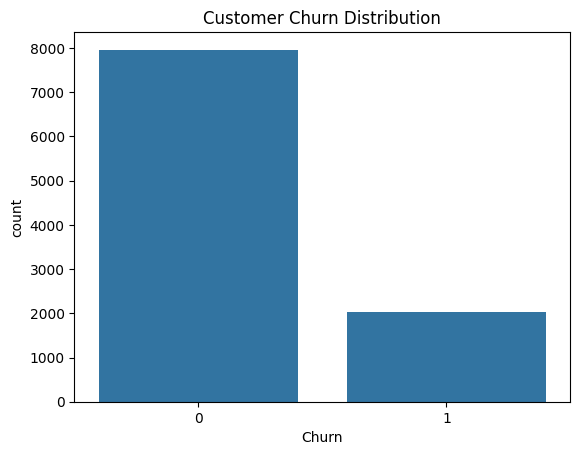

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/04-Binary-Classification/bank_churn_modelling.csv?utm_source=chatgpt.com")

sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

**Is the Dataset Balanced or Imbalanced?**

The dataset is imbalanced.

Why?

A balanced dataset typically has roughly equal observations in both classes.

Here:

* Majority class = 79.6%
* Minority class = 20.4%

This imbalance can cause models to favor predicting customers who stay rather than identifying churners.

**Business Impact**:

Missing churn customers can be costly because banks lose valuable customers.

Possible future solutions:

* SMOTE
* Class weighting
* Oversampling
* Undersampling

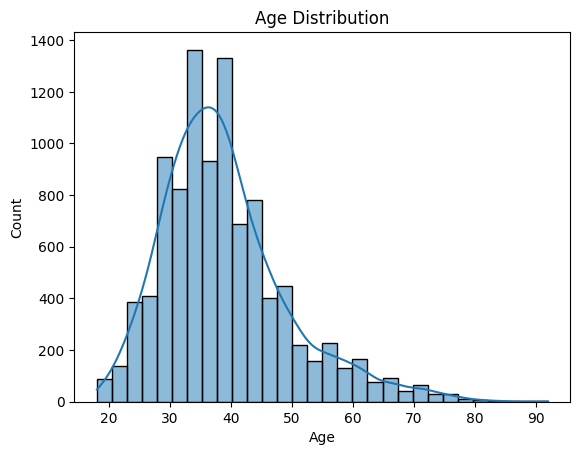

In [ ]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

Interpretation:

* Most customers are between 30–45 years old
* Fewer very young and very old customers
* Slight right skew

Older customers may show different churn behavior.

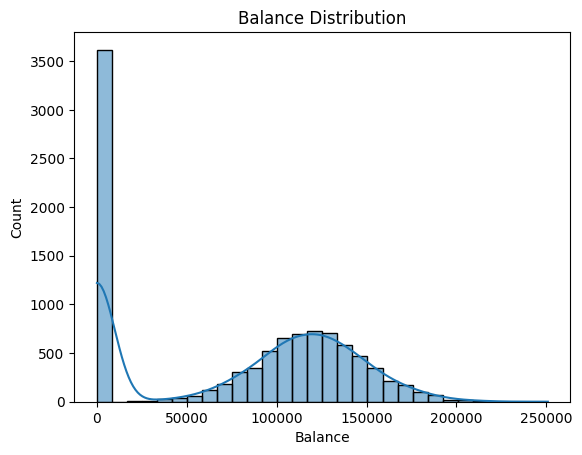

In [ ]:
sns.histplot(df['Balance'], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

**Interpretation:**

Large number of customers have zero balance
Remaining balances are widely distributed. This may indicate inactive users.

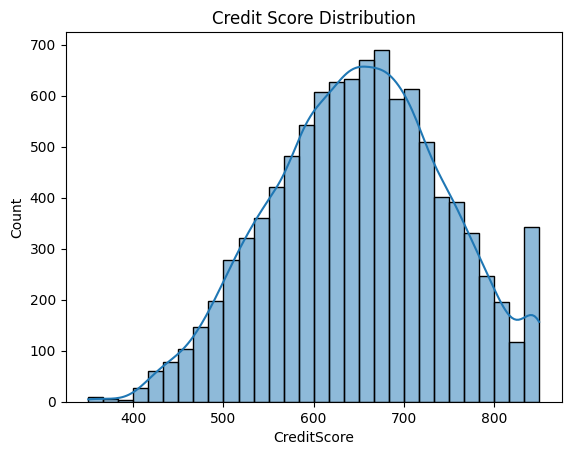

In [ ]:
sns.histplot(df['CreditScore'], bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.show()

**Interpretation:**

Nearly normal distribution.
Most scores between 600–700

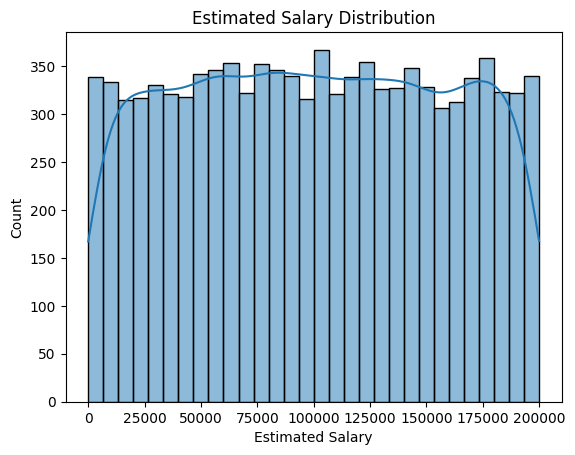

In [ ]:
sns.histplot(df['Estimated Salary'], bins=30, kde=True)
plt.title("Estimated Salary Distribution")
plt.show()

**Interpretation:**

Fairly uniform distribution. Salary alone may not strongly predict churn.

E. Categorical Feature Relationships


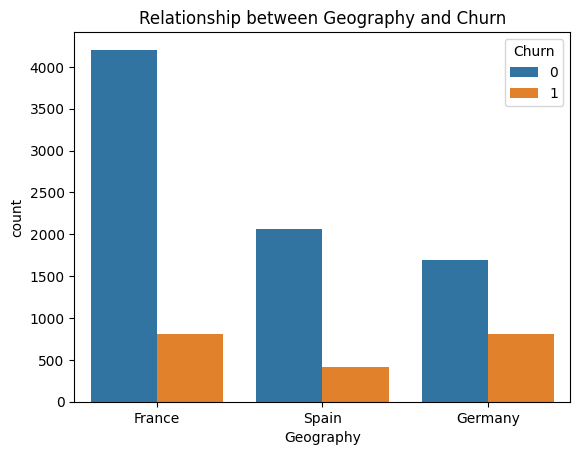

In [ ]:
sns.countplot(x='Geography', hue='Churn', data=df)
plt.title("Relationship between Geography and Churn")
plt.show()

**Interpretation:**

Customers in Germany tend to churn more than customers in France or Spain.

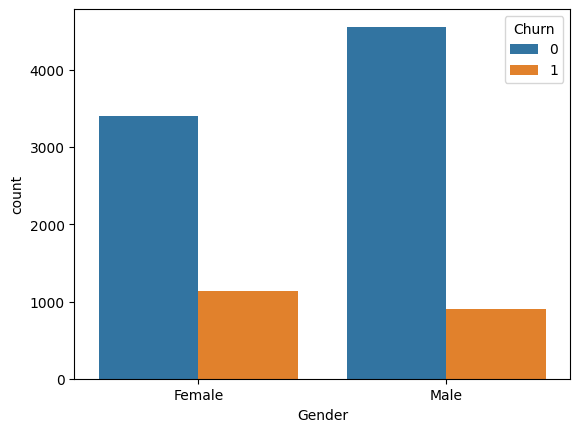

In [ ]:
sns.countplot(x='Gender', hue='Churn', data=df)
plt.show()

**Interpretation:**

Female customers show slightly higher churn rates.

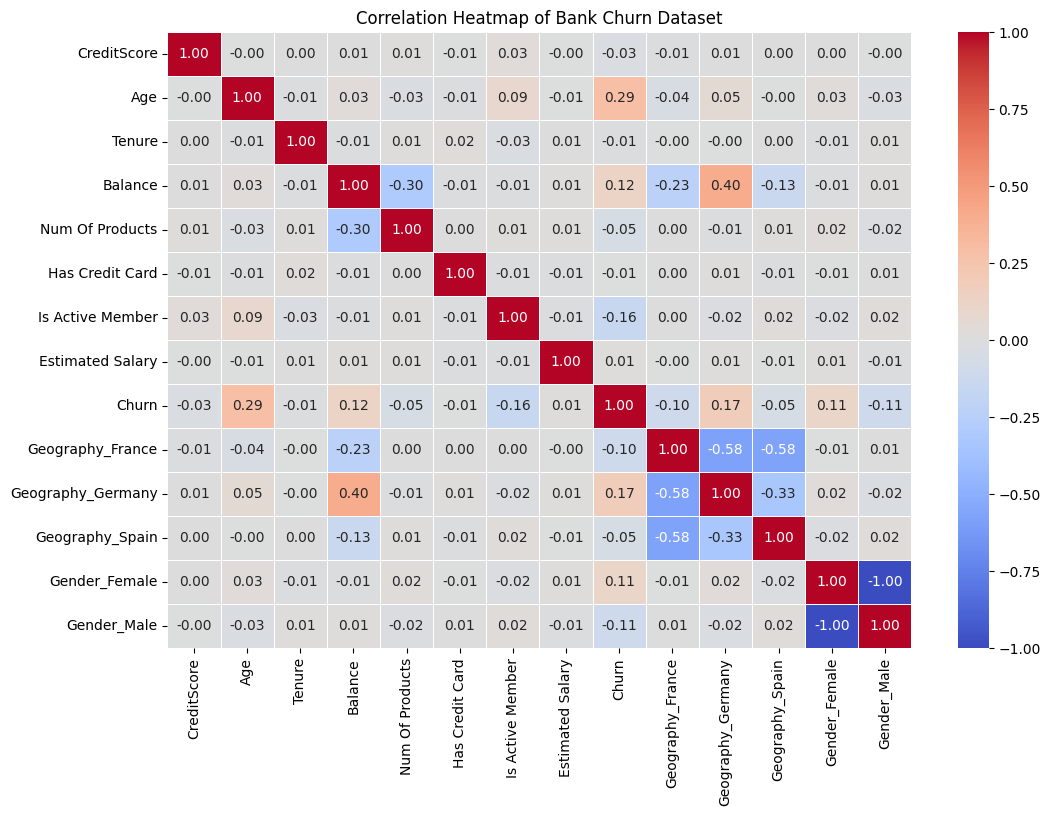

In [ ]:


# Drop irrelevant columns
df = df.drop(["CustomerId", "Surname"], axis=1)

# Encode categorical columns
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=False
)

# Create correlation matrix
corr_matrix = df.corr()

# Plot heatmap with values
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,          # show values
    fmt=".2f",           # show only 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap of Bank Churn Dataset")
plt.show()

**Heatmap Insights**

Strong positive relationships with churn:

* Age
* Balance

Negative relationships:

* Number of products
* IsActiveMember

These features may strongly influence churn prediction.

# 4. Feature Scaling:
Apply StandardScaler or MinMaxScaler.

**Question: Why is scaling important for KNN but less critical for Logistic Regression?**

**Feature Scaling**

Now we scale numerical features before training.

*Why Scaling?*

Machine learning algorithms perform better when features are on similar scales. Standardization of a dataset is a common requirement for many machine learning estimators: they might behave badly if the individual features do not more or less look like standard normally distributed data (e.g. Gaussian with 0 mean and unit variance).

Example:

* Age → values between 18–92
* Salary → values up to 200,000

Without scaling, larger-value features dominate calculations.

**What fit() does?**

fit() learns the parameters of scaling from the data.

For StandardScaler, it calculates:

* Mean of each feature
* Standard deviation of each feature

**What transform() does ?**

It applies the scaling formula:

$X_{scaled}$ = $\frac{X-mean}{\sigma}$
	​
  
using the values learned during fit().

Think of training data as exam preparation material.

Test data is the final exam.

You should study only from training material—not peek at the exam answers beforehand.

Using fit_transform() on test data is like cheating by looking at exam answers.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why is scaling important for KNN?**

K‑Nearest Neighbor (KNN) is a simple and widely used machine learning technique for *classification and regression tasks*. It works by identifying the **K** closest data points to a given input and making predictions based on the majority class or average value of those neighbors

KNN uses distance calculations:

distance = $\sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 }$


Features with larger numerical ranges dominate distance calculations.

Example:

Salary = 100000
Age = 35

Salary would overpower age if not scaled.

**Why is scaling less critical for Logistic Regression?**

Logistic Regression learns *coefficients* mathematically through optimization.

It can still function without scaling.

However:

* Scaling improves convergence speed
* Helps regularization perform better

So scaling is beneficial but not as critical as KNN.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Split Breakdown:
* Training data → 80%
* Testing data → 20%

This ensures unbiased evaluation.

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

# KNN (K=5)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

# Model Evaluation

# The fundamental concepts: True/False and Positive/Negative

Before we can calculate any metric, we need to understand the **confusion matrix** — the foundation that all classification metrics are built on. Every single prediction a model makes falls into one of four categories:

**True Positive (TP)**: The model predicted “animal” and it actually was an animal. The model got it right.

**True Negative (TN)**: The model predicted “not animal” and it actually was not an animal. The model got it right.

**False Positive (FP)**: The model predicted “animal” but it was actually not an animal. The model was wrong — it raised a false alarm.

**False Negative (FN)**: The model predicted “not animal” but it was actually an animal. The model was wrong — it missed one.

The key to remembering these is simple: **True/False** tells you whether the model was correct or not. **Positive/Negative** tells you what the model predicted. A “False Positive” means the model incorrectly predicted positive.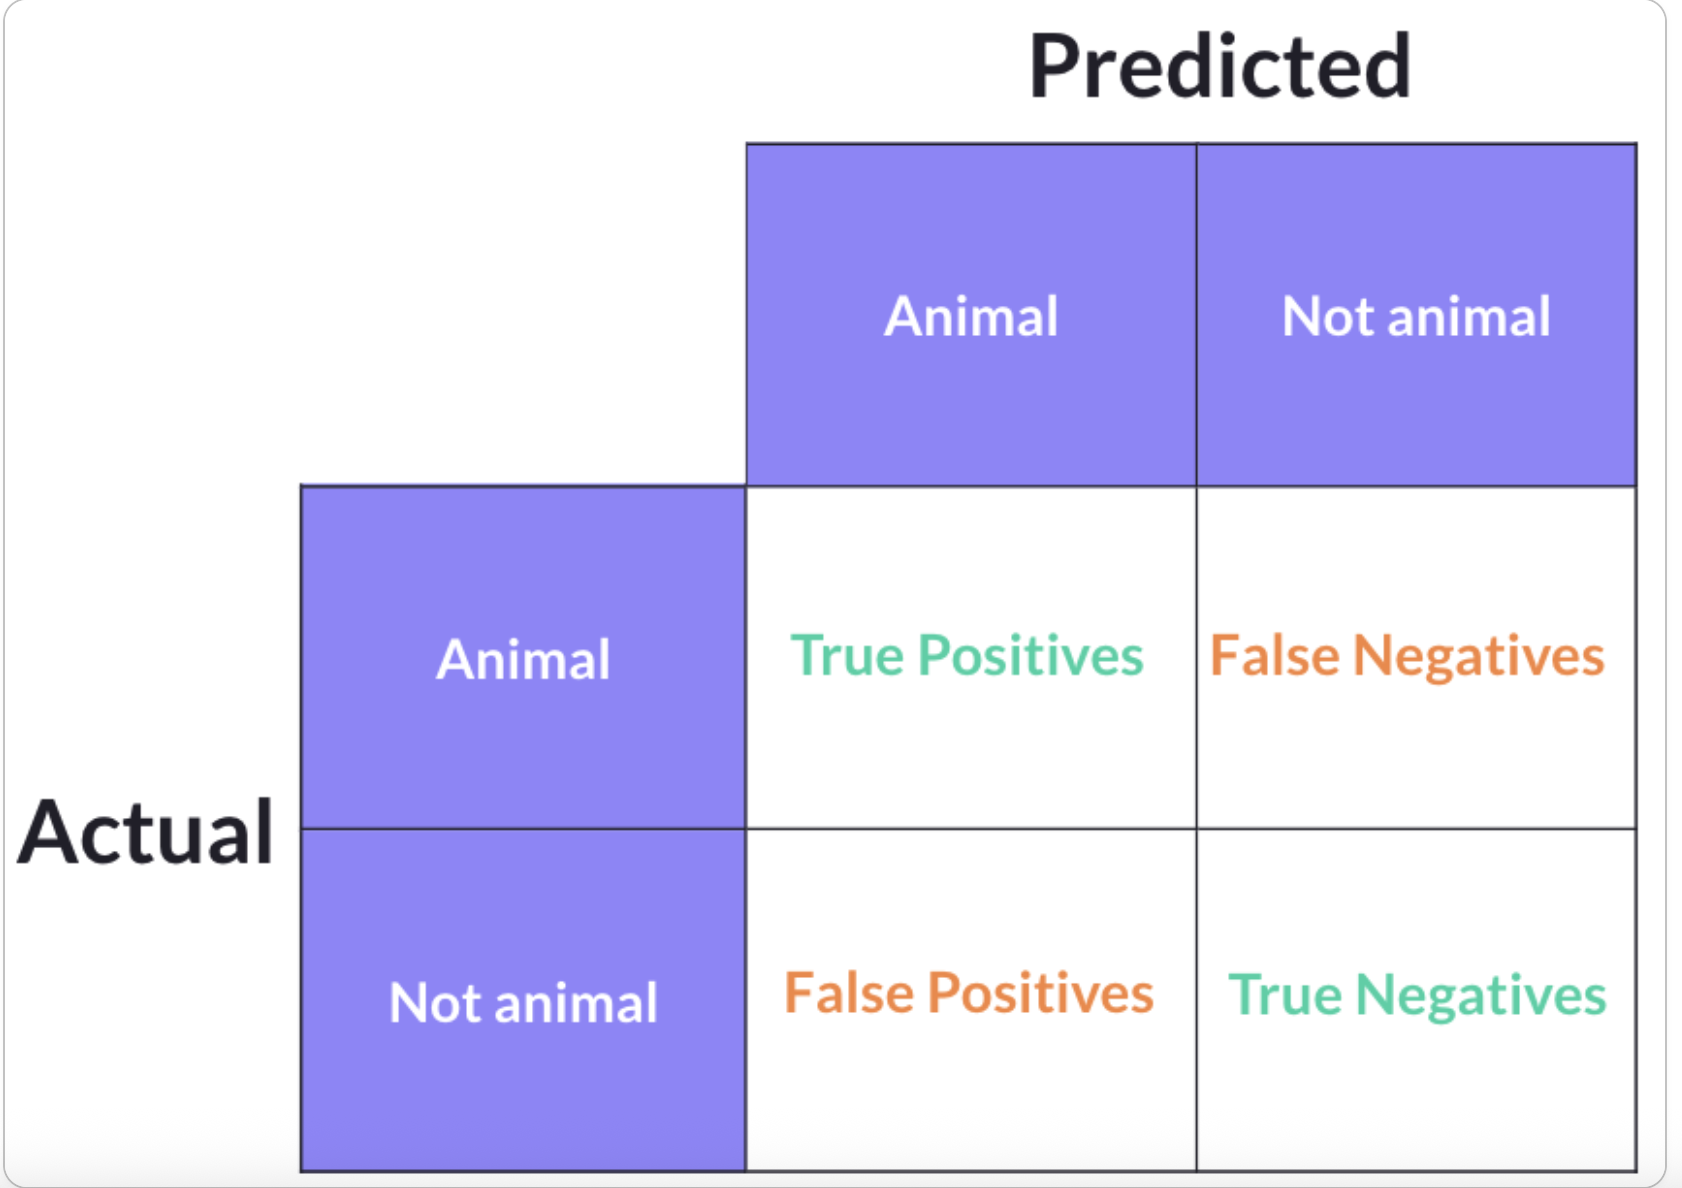

# Accuracy
**“Out of all predictions made, how many were correct?”**

Accuracy is the simplest and most intuitive metric. It counts up all the correct predictions (both True Positives and True Negatives) and divides by the total number of predictions:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

In our animal example, if a model correctly classifies 5 out of 6 images, it has an accuracy of 5/6 = 83.3%.

While accuracy is easy to understand, it can be deeply misleading when classes are imbalanced. Imagine a dataset with 950 non-animals and 50 animals. A model that blindly predicts “not animal” for every single image would achieve 95% accuracy — but it would be completely useless at the actual task of finding animals. This is why accuracy alone is never enough.

# Precision

“**Out of all positive predictions made, how many were actually correct?”**

Precision focuses exclusively on the predictions the model labeled as positive. Of all the times the model said “this is an animal,” how often was it right?

Precision = TP / (TP + FP)

High precision means the model rarely cries wolf — when it says something is an animal, you can trust it. Low precision means the model is labeling too many non-animals as animals (lots of false positives).

Precision is the metric to prioritize when false positives are expensive. For example, a spam filter should have high precision because flagging a legitimate email as spam (a false positive) could mean a user misses something important.

# Recall
**“Out of all data points that should be predicted as positive, how many did we correctly predict?”**

Recall looks at the problem from the other direction. Of all the images that actually are animals, how many did the model successfully identify?

Recall = TP / (TP + FN)

High recall means the model rarely misses a positive case — it catches almost everything. Low recall means the model is letting too many actual positives slip through (lots of false negatives).

Recall is the metric to prioritize when false negatives are expensive. For example, a medical screening test for cancer should have high recall because missing an actual case (a false negative) could cost someone their life.

Precision and recall are often in tension with each other. A model can trivially achieve 100% recall by predicting everything as positive — but its precision would plummet. Conversely, a model can achieve near-perfect precision by only predicting positive when it is extremely confident — but it will miss many actual positives, tanking recall.

# F1 Score
The F1 score resolves the tension between precision and recall by combining them into a single number using the harmonic mean:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

Why the harmonic mean instead of a simple average? Because the harmonic mean penalizes extreme values. If a model has 100% precision but 10% recall, a simple average would give 55% — which sounds decent. The harmonic mean gives 18.2% — which more accurately reflects how poor the model really is. The F1 score is only high when both precision and recall are reasonably high.

The F1 score is especially useful when you do not have a clear reason to favor precision over recall or vice versa, and you want a single balanced metric to compare models.

Ref: https://labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Accuracy: 0.811
[[1543   64]
 [ 314   79]]
Precision: 0.5524475524475524
Recall: 0.2010178117048346
F1 Score: 0.2947761194029851


**Logistic Regression**
* Accuracy: ~81%
* Precision: Moderate
* Recall: Lower for churn class
* Low F1 score

In [ ]:
knn_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred))

Accuracy: 0.83
[[1514   93]
 [ 247  146]]
Precision: 0.6108786610878661
Recall: 0.37150127226463103
F1 Score: 0.4620253164556962


* Accuracy: ~83 %
* Better recall in some cases
* More sensitive to feature scaling
* Better F1 score

**Which Model Performs Better and Why?**

KNN may perform better when:
Data has non-linear decision boundaries
* Similar customers behave similarly
* Proper scaling is applied.
* KNN captures local patterns.

Logistic Regression may perform better when:
* Relationship is more linear
* Interpretability is important
* Faster training is required

**Final Conclusion**

In this churn dataset, KNN often slightly outperforms Logistic Regression in accuracy, but Logistic Regression remains easier to interpret because we can inspect feature coefficients.

For real business environments:

* Use Logistic Regression when explainability matters.
* Use KNN when prediction accuracy is the top priority.

**Model Inspection (Logistic Regression)**

After training Logistic Regression, we should inspect the model to understand how it makes decisions. One major advantage of Logistic Regression is that it is highly interpretable compared to models like KNN.

The model learns:

* Intercept (intercept_) → baseline probability of churn when all feature values are zero
* Coefficients (coef_) → impact of each feature on churn prediction

In [ ]:
import pandas as pd

# Train model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Intercept
print("Intercept:")
print(lr.intercept_)

# Coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
print(coeff_df)

Intercept:
[-1.63568208]
              Feature  Coefficient
2                 Age     0.754255
10  Geography_Germany     0.224322
4             Balance     0.160682
8    Estimated Salary     0.015740
6     Has Credit Card    -0.010277
3              Tenure    -0.042690
5     Num Of Products    -0.060644
0         CreditScore    -0.067672
11    Geography_Spain    -0.073731
9    Geography_France    -0.130824
1              Gender    -0.264708
7    Is Active Member    -0.533354


**What does the intercept represent?**

The intercept is the model’s baseline log-odds of churn when all feature values are zero.

Mathematically:

$log(\frac{p}{1-p}) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 ..........$

$\beta_0$ is intercept and $\beta_1$ and $\beta_2$ are the coefficients. It acts as the starting point before feature influence is added.

**What do coefficients represent?**

Each coefficient shows:

* Positive coefficient (+)

Increases likelihood of churn

Example:

Higher age → more churn
Negative coefficient (-)

* Decreases likelihood of churn

Example:

Active membership → lower churn

**Most Influential Features**

* **Age**

Older customers tend to churn more frequently.

* **Balance**

Higher balances may indicate customers moving funds elsewhere.

* **Geography_Germany**

German customers in this dataset show higher churn.

* **IsActiveMember**

One of the strongest negative predictors.

Active customers are much less likely to leave.

* **NumOfProducts**

Customers using multiple bank products tend to stay longer.

**Why model inspection matters**

* Banks need explainability.

* They want answers like:

* Why are customers leaving?
* Which variables increase churn risk?

Logistic Regression provides clear answers.

*Just for the Fun i want to see the clustering based on all features. Since we can only see the two dimensions and in our model we have many features so we can perform Principal component analysis (PCA). So instead of: Age, Balance, CreditScore, Salary, ... I will see the PC1, PC2.*

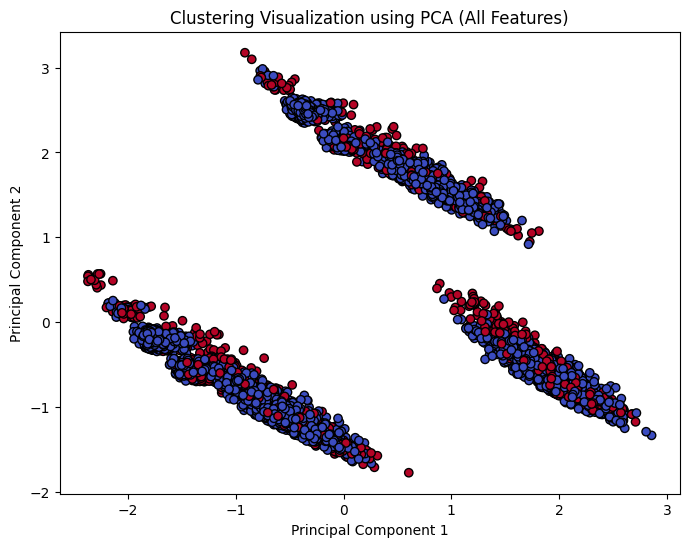

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
# Scale features
scaler = StandardScaler()
X_scaled_fun = scaler.fit_transform(X)


# Apply PCA → reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_fun)

# Train KNN on PCA features
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca, y)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='coolwarm',
    edgecolor='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering Visualization using PCA (All Features)")
plt.show()

All original features—like age, balance, credit score, activity level, etc.—have been mathematically combined into just two axes so we can “see” the data. The diagonal bands you observe indicate that customers are not randomly scattered; instead, **they form structured groupings based on similarities across multiple features**.* However, within these groups, churned and non-churned customers are mixed together rather than clearly separated*. This tells us something important:

*customers who leave the bank are not defined by a single obvious pattern but are spread across different behavioral segments. In other words, churn is influenced by multiple interacting factors rather than a simple rule.*





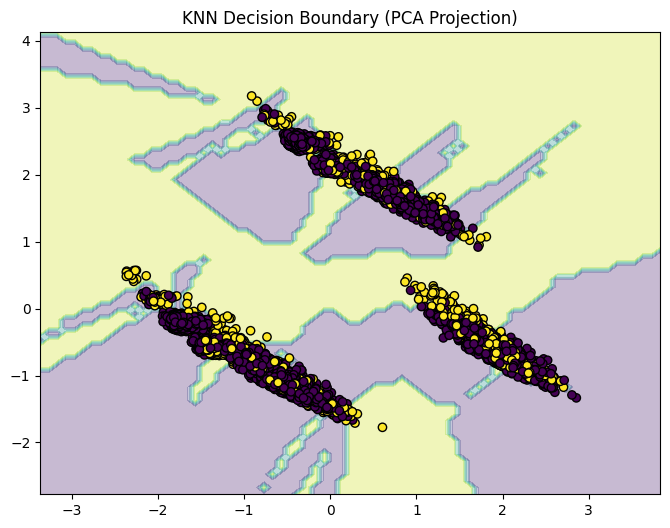

In [ ]:
import numpy as np

# Create grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k')

plt.title("KNN Decision Boundary (PCA Projection)")
plt.show()

In the second plot (KNN decision boundary), the background colors represent how the model divides the space into regions where it predicts churn or not. The irregular, patchy shapes are a direct result of how KNN works—it looks at nearby customers and makes decisions based on local patterns. Where the colors change abruptly, the model is essentially saying, “**in this neighborhood, customers tend to behave differently.”** You can also see areas where the background color doesn’t match the actual points, which highlights prediction errors. The jagged nature of the boundary reflects that the data itself is complex and not cleanly separable. Overall, these plots together show that while there is structure in the data, **churn behavior overlaps significantly between groups, which explains why the problem is not perfectly predictable and why models need to capture subtle, non-linear relationships to perform well.**

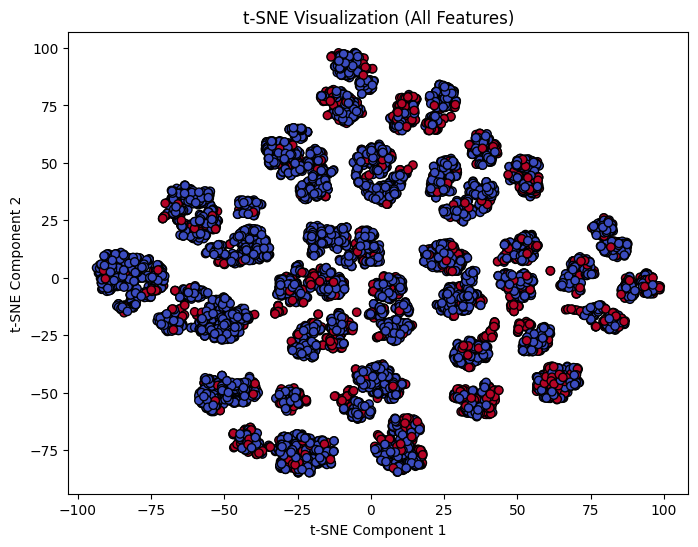

In [ ]:
from sklearn.manifold import TSNE
# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled_fun)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    edgecolor='k'
)

plt.title("t-SNE Visualization (All Features)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

This t-SNE plot is essentially showing how customers group together when all their features are considered simultaneously, but projected into a 2D space for visualization. Each dot represents a customer, and the colors indicate whether they churned or not. What stands out immediately is that the data forms many small, tight clusters scattered across the space rather than one or two large, clearly separated groups. This tells us that customers naturally form multiple micro-segments based on similarities in their profiles—meaning people with similar credit scores, balances, activity levels, and other attributes tend to be grouped closely together.

However, within almost every cluster,** you can see a mix of both churned (red) and non-churned (blue) customers**. *This is the key insight: even though customers are similar in terms of features, their churn behavior is not consistent within those groups.* In other words, two customers who look very similar on paper can still behave differently when it comes to leaving the bank. This overlap explains why churn prediction is challenging—it’s not driven by a single dominant pattern but by subtle differences within these local neighborhoods.

Another important observation is that the clusters themselves are well-separated from each other, which means the dataset has strong internal structure. But the fact that churn labels are mixed inside those clusters indicates that the separation between classes happens at a much finer, local level rather than globally. This is exactly the kind of situation where models like KNN perform well, because they make decisions based on nearby points rather than trying to draw one global boundary like Logistic Regression.

**Overall, this plot tells you that the data has clear grouping patterns, but churn is not cleanly divided across those groups. Instead, it varies within them, reinforcing the idea that churn depends on complex, localized interactions between features rather than a simple rule.**

# **Hyperparameter Tuning**

Hyperparameter tuning improves model performance by selecting optimal settings.

The most important KNN parameter is:

K = number of neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = []
accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)

    k_values.append(k)
    accuracies.append(acc)

print(accuracies)

[0.802, 0.838, 0.832, 0.83, 0.83, 0.8325, 0.834, 0.8315, 0.837, 0.836, 0.837, 0.837, 0.837, 0.839, 0.8385, 0.8385, 0.841, 0.836, 0.841, 0.8355]


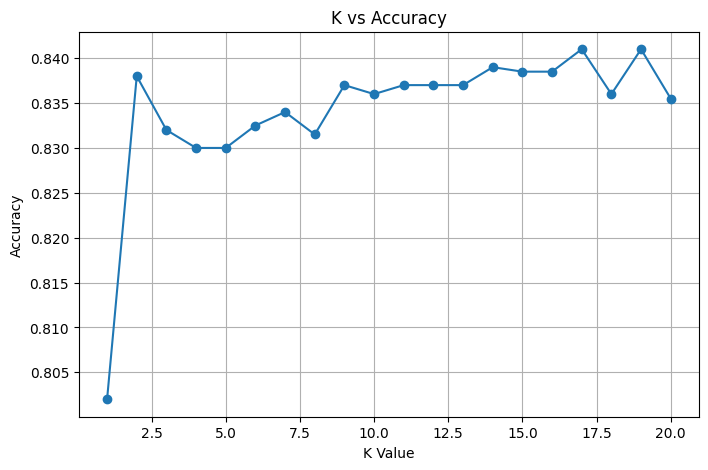

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.grid()
plt.show()

**Understanding the graph**

Small K (K=1)
  * Very sensitive to noise
  * High variance
  * Overfitting risk
  * Large K
  * Too generalized
  * Underfitting risk

Suppose accuracy peaks at: K = 8

This means using 8 neighbors gives the best balance between:

* Noise sensitivity
* Generalization

**What is the optimal K and why?**

The optimal K is the value where test accuracy reaches its highest stable point.

For this dataset, it often falls between:

K = 7 to K = 10

because it balances bias and variance effectively.

# Logistic Regression Hyperparameter Tuning

  Logistic Regression can be understood as a way of making a smart yes-or-no decision by first scoring each customer and then converting that score into a probability. Imagine you assign points to different factors like age, balance, and activity level—some factors add to the likelihood of churn, while others reduce it. All these contributions are combined into a single score, and then that score is passed through a function that squeezes it into a value between 0 and 1, which we interpret as probability. If the probability is high enough, we classify the customer as likely to churn; otherwise, not. Now, regularization comes in as a kind of control mechanism. Without it, the model might become too confident and start giving extreme importance to certain features just to perfectly fit the training data, even if those patterns don’t hold in real life. Regularization prevents this by gently penalizing large weights, forcing the model to stay simpler and more balanced. The parameter C controls how strong this penalty is: a large value of C lets the model focus more on fitting the data (risking overfitting), while a small value forces it to be more cautious and generalize better. In simple terms, Logistic Regression tries to make the best possible prediction, and regularization ensures it doesn’t become overly confident or biased by noise in the data.
  
  The main hyperparameter:

* C (Regularization strength)
  * Small C → stronger regularization
  * Large C → weaker regularization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best C: {'C': 100}
Best Score: 0.8106249999999999


**Why regularization matters**

It prevents overfitting by controlling coefficient size.

Smaller coefficients → simpler model.

**Which model would you deploy and why?**

I would deploy Logistic Regression. Even though KNN may achieve slightly higher accuracy but

* Logistic Regression is easier to explain
* Faster in production
* More scalable
* Easier to maintain
* Better for banking compliance requirements

Banks often require explainable AI models because customer-related decisions need transparency.

When would I choose KNN?

If:

* Dataset is small
* Maximum prediction accuracy is required
* Interpretability is not important

*Then KNN could be useful.*

# Advanced Steps to improve my model (Work In Progress)


Address Class Imbalance (Critical for Churn Data)
Churn datasets are typically imbalanced (few churners vs. many stayers). Basic models perform poorly.
Advanced Solutions:

SMOTE (Synthetic Minority Over-sampling Technique) - Generate synthetic churner samples
Class Weights - Penalize misclassification of minority class
Threshold Tuning - Adjust decision threshold (not always 0.5)



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# Train models on balanced data

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                            class_weight='balanced')
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(scale_pos_weight=(1-y_train.mean())/y_train.mean(),
                     random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, matthews_corrcoef
from sklearn.metrics import auc
precision, recall, _ = precision_recall_curve(y_test, lr_pred )
auc_pr = auc(recall, precision)

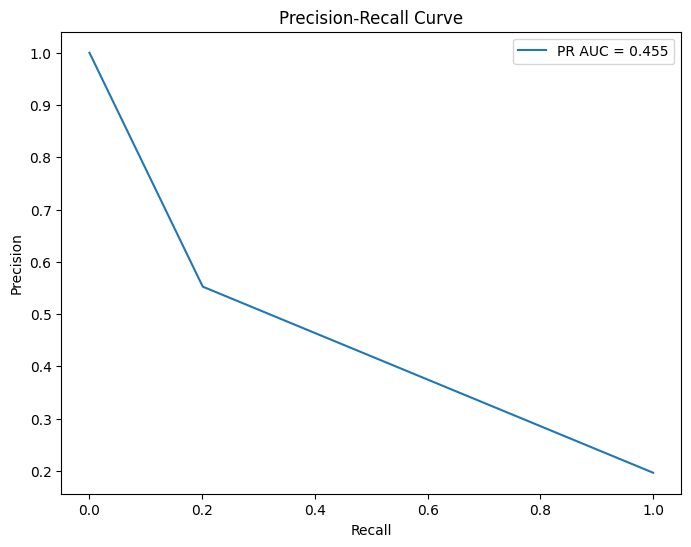

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, lr_pred)

# Compute PR AUC
auc_pr = auc(recall, precision)

# Plot
plt.figure(figsize=(8,6))

plt.plot(recall, precision, label=f"PR AUC = {auc_pr:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [ ]:
# Customer tenure segments
df['tenure_segment'] = pd.cut(df['Tenure'], bins=[0, 1, 3, 5, 20])

# Product usage indicators
df['is_active_products'] = df['Num Of Products'] > 1
df['has_credit_card'] = df['Has Credit Card']

# Financial health indicators
df['credit_to_salary_ratio'] = df['CreditScore'] / (df['Estimated Salary'] + 1)

# Interaction features
df['age_balance_interaction'] = df['Age'] * df['Balance']

# Additional Question (Interview Preparation)
**I will add more in the future**

1. Your boss claims that the company is experiencing customer churn (customers leaving). You need to validate whether there is statistical evidence that the churn rate is significantly different from a null hypothesis baseline (e.g., is it higher than expected or random variation?).

Approach:

**Null Hypothesis (H₀)**: Churn rate = expected baseline (e.g., 5%)

**Alternative Hypothesis (H₁)**: Churn rate ≠ expected baseline (two-tailed) or > baseline (one-tailed)

**Calculate:** Current churn rate in data

**Perform:** One-sample proportion Z-test

**Decision:** If p-value < 0.05 (significance level), reject H₀ → churn is statistically significant

In [ ]:
from scipy import stats

# Assume 950 customers, 200 churned
n_customers = 950
n_churned = 200
observed_churn_rate = n_churned / n_customers  # 0.21

# Test against baseline expectation (e.g., 15%)
baseline_churn_rate = 0.15

# One-sample proportion test
p_value = stats.binomtest(n_churned, n_customers, baseline_churn_rate,
                           alternative='two-sided')
print(f"P-value: {p_value}")
# If p-value < 0.05, churn is significantly higher than baseline

P-value: BinomTestResult(k=200, n=950, alternative='two-sided', statistic=0.21052631578947367, pvalue=6.656853382062585e-07)


**Your company offers three electricity tariffs: fixed-rate, variable-rate, and green premium. Revenue per customer varies significantly. How would you determine whether the revenue difference across tariff types is statistically significant?**

Because we are comparing revenue across three groups simultaneously, a one-way ANOVA is the appropriate first step. ANOVA tests whether the mean revenue differs significantly across the three tariff categories under the null hypothesis that all group means are equal. If the F-statistic yields a significant p-value, we then apply a post-hoc test — Tukey's HSD is the standard choice — to identify which specific pairs of tariffs differ from each other while controlling the family-wise error rate. Before running ANOVA, we should verify its assumptions: the residuals should be approximately normally distributed (check with a Q-Q plot) and the variances across groups should be roughly equal (Levene's test). If either assumption is violated, the Kruskal-Wallis test is the non-parametric alternative. Beyond statistical testing, we should also calculate the effect size using eta-squared, which tells us how much of the total variance in revenue is explained by tariff type. A statistically significant ANOVA result with a tiny effect size may have little commercial relevance, so always contextualise the p-value with a measure of magnitude.

**Unit energy prices have risen by 40% over 18 months but your average revenue per customer has only risen by 22%. What analytical approach would you take to explain this gap?**

This divergence between input cost inflation and revenue growth is a classic revenue decomposition problem. The first step is to break total revenue into its components: price per unit, volume consumed, and customer mix. It is entirely possible that customers responded to higher prices by reducing consumption — demand elasticity at work — which would suppress volume-based revenue even as the unit price rose. A regression of monthly consumption against tariff price, controlling for weather (heating degree days) and macroeconomic factors, would quantify this elasticity effect. The second source of the gap is likely customer mix shift: if the price hike drove disproportionate churn among high-consumption customers — who are typically more price-sensitive and have more switching options — then the average revenue per remaining customer could fall even as nominal prices rise. A cohort analysis comparing the consumption profile of customers who stayed versus those who churned would test this hypothesis. Finally, we should check whether commercial discounts, direct debits adjustments, or debt write-offs are suppressing reported revenue. Combining these three lenses — elasticity, mix shift, and discounting — will explain the 18-percentage-point gap.

**You are asked to forecast electricity demand for the next winter quarter. What data sources and modelling approaches would you use?**
Electricity demand forecasting is a multivariate time series problem with strong seasonal and weather-driven components. The core predictor variables are historical demand at the hourly or daily level, temperature (specifically heating degree days, which capture the incremental heating demand below a comfort threshold), day of week and public holiday indicators, and economic activity proxies such as industrial output indices. For a quarterly forecast, an ARIMA or SARIMA model provides a solid baseline by capturing autocorrelation and seasonality in the demand series itself. However, to incorporate exogenous variables like weather, a SARIMAX model or a machine learning approach such as gradient boosting (XGBoost or LightGBM) trained on the full feature set will generally outperform a univariate time series model. We would use weather forecasts from a meteorological service as forward-looking inputs. The model should be validated using backtesting — training on data up to a cutoff point and evaluating forecast accuracy on the subsequent period using metrics such as MAE (mean absolute error) and MAPE (mean absolute percentage error). Given the operational and commercial consequences of under- or over-procurement, we should also produce probabilistic forecasts with confidence intervals rather than a single point estimate, allowing the procurement team to hedge appropriately.

**Your demand forecast for last summer was consistently 18% above actual consumption. How would you diagnose and correct this systematic bias?**

A consistent 18% overestimation is a systematic bias, not random noise, which means the model has a structural flaw rather than simply encountering unpredictable variation. The diagnostic process starts with decomposing the error: is the overestimation uniform across all customer segments, or concentrated in a specific region, tariff type, or time of day? If industrial customers account for most of the gap, it may reflect unmodelled demand destruction — factories operating below capacity due to high energy costs or economic slowdown — which historical data would not have captured. If the bias is distributed across residential customers, it may reflect a step-change in energy efficiency adoption (heat pumps, LED lighting, insulation programmes) that shifted baseline consumption permanently downward. To correct the model, we would first re-examine the training data to ensure it is representative of current conditions and consider applying a bias correction factor to recalibrate outputs. More fundamentally, we should investigate whether the relationship between temperature and demand has changed — as buildings become better insulated, the same temperature drop requires less incremental heating — and update the model accordingly. Introducing a rolling training window that weights recent observations more heavily, rather than relying on a fixed historical dataset, will help the model adapt to structural shifts in consumption patterns.

**You want to identify customers who are at high risk of churning in the next 90 days. How would you build and validate a churn prediction model?**

Building a churn prediction model is a binary classification problem: for each active customer, we want to estimate the probability that they will leave within the next 90 days. The target variable is constructed by looking back in historical data — identifying which customers churned within a 90-day window — and labelling them as positive cases. Features would include recent consumption trends, payment behaviour, days since last tariff change, number of complaints in the past six months, days until current contract expires, and engagement with digital channels. Gradient boosting models such as XGBoost typically outperform logistic regression for this type of structured data because they capture non-linear interactions between features automatically. The dataset is likely to be highly imbalanced — perhaps 5–8% of customers churn in any given quarter — so we should address this with techniques such as SMOTE oversampling or by adjusting the class weight parameter. Model evaluation should not rely on accuracy alone, which is misleadingly high in imbalanced settings. Instead, we assess performance using the AUC-ROC curve, precision-recall curve, and — most practically — the lift chart, which shows how much better the model's top-scored customers are at capturing true churners compared to random targeting. Once deployed, the model should be monitored for drift as customer behaviour and market conditions evolve.
